In [0]:
%sh
mkdir -p /tmp/xena_raw
wget -O /tmp/xena_raw/expression.tsv.gz "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.star_fpkm-uq.tsv.gz"
wget -O /tmp/xena_raw/clinical.tsv.gz "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FBRCA_clinicalMatrix"
ls -lh /tmp/xena_raw/

--2026-07-03 16:59:10--  https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.star_fpkm-uq.tsv.gz
Resolving gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)... 16.182.65.66, 52.217.82.120, 54.231.136.186, ...
Connecting to gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)|16.182.65.66|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 317153612 (302M) [text/tab-separated-values]
Saving to: ‘/tmp/xena_raw/expression.tsv.gz’

     0K .......... .......... .......... .......... ..........  0% 3.76M 80s
    50K .......... .......... .......... .......... ..........  0% 3.49M 84s
   100K .......... .......... .......... .......... ..........  0% 3.76M 82s
   150K .......... .......... .......... .......... ..........  0% 3.77M 82s
   200K .......... .......... .......... .......... ..........  0% 3.75M 82s
   250K .......... .......... .......... .......... ..........  0% 1.94M 94s
   300K .......... .......... ...

In [0]:
%sh
echo "--- file types ---"
file /tmp/xena_raw/expression.tsv.gz
file /tmp/xena_raw/clinical.tsv.gz

echo "--- expression head (first 3 lines, first 5 fields) ---"
zcat /tmp/xena_raw/expression.tsv.gz 2>/dev/null | head -3 | cut -f1-5

echo "--- clinical: does PAM50Call_RNAseq exist? ---"
(zcat /tmp/xena_raw/clinical.tsv.gz 2>/dev/null || cat /tmp/xena_raw/clinical.tsv.gz) | head -1 | tr '\t' '\n' | grep -n -i pam50

--- file types ---
/tmp/xena_raw/expression.tsv.gz: gzip compressed data, was "TCGA-BRCA.star_fpkm-uq.tsv", last modified: Wed May 22 18:27:31 2024, from Unix, original size modulo 2^32 910147282
/tmp/xena_raw/clinical.tsv.gz: ASCII text, with very long lines (6817)
--- expression head (first 3 lines, first 5 fields) ---
Ensembl_ID	TCGA-D8-A146-01A	TCGA-AQ-A0Y5-01A	TCGA-C8-A274-01A	TCGA-BH-A0BD-01A
ENSG00000000003.15	3.7677077596382405	2.1327413367173778	4.768009602504174	3.049735307055894
ENSG00000000005.6	1.7594541446196026	0.1460034511389246	0.0	1.0717626693000917
--- clinical: does PAM50Call_RNAseq exist? ---
13:Integrated_Clusters_with_PAM50__nature2012
20:PAM50Call_RNAseq
21:PAM50_mRNA_nature2012


In [0]:
%sql
CREATE VOLUME IF NOT EXISTS workspace.default.xena_raw

In [0]:
%sh
# Volumes are FUSE-mounted, so a plain cp/mv works — no special API needed
cp /tmp/xena_raw/expression.tsv.gz /Volumes/workspace/default/xena_raw/expression.tsv.gz
cp /tmp/xena_raw/clinical.tsv.gz /Volumes/workspace/default/xena_raw/clinical.tsv   # dropped .gz — it's not actually compressed

ls -lh /Volumes/workspace/default/xena_raw/

total 305M
-rwxrwxrwx 1 nobody nogroup 1.7M Jul  3  2026 clinical.tsv
-rwxrwxrwx 1 nobody nogroup 303M Jul  3 16:59 expression.tsv.gz


In [0]:
expression_df = (
    spark.read
    .option("header", True)
    .option("sep", "\t")
    .option("inferSchema", False) 
    .csv("/Volumes/workspace/default/xena_raw/expression.tsv.gz")
)

clinical_df = (
    spark.read
    .option("header", True)
    .option("sep", "\t")
    .csv("/Volumes/workspace/default/xena_raw/clinical.tsv")
)

print(type(expression_df))

<class 'pyspark.sql.connect.dataframe.DataFrame'>


In [0]:
n_genes = expression_df.count()
n_samples = len(expression_df.columns) - 1  # minus the Ensembl_ID column
print(f"genes: {n_genes}, samples: {n_samples}")

genes: 60660, samples: 1226


In [0]:
from pyspark.sql import functions as F

sample_cols = [c for c in expression_df.columns if c != "Ensembl_ID"]

# 1. Cast the ~1,226 sample columns to double.
#    Still a transformation, not an action -- no execution yet.
expression_typed = expression_df.select(
    "Ensembl_ID",
    *[F.col(c).cast("double").alias(c) for c in sample_cols]
)

# Sanity check: are values already log-scale? Real FPKM-UQ maxes are usually
# in the thousands; log2(x+1) maxes are usually under ~20.
print(expression_typed.select(F.max(sample_cols[0])).collect())


[Row(max(TCGA-D8-A146-01A)=12.595967090483322)]


In [0]:
# 2. MELT: wide (gene x 1,226 sample columns) -> long (Ensembl_ID, sample_barcode, expression_value)
#    stack() needs 'label, column' pairs listed explicitly -- with ~1,200 columns this
#    can trip Spark's codegen size limit (a "grows beyond 64 KB" WARNING). If you see that
#    warning, it's not fatal -- Spark just falls back to a slower execution path -- paste it
#    back and we'll switch to a chunked union approach if it's actually failing (not just warning).
n = len(sample_cols)
stack_cols = ", ".join([f"'{c}', `{c}`" for c in sample_cols])
melted = expression_typed.select(
    "Ensembl_ID",
    F.expr(f"stack({n}, {stack_cols}) as (sample_barcode, expression_value)")
)

In [0]:
# 3. Per-gene mean + variance in ONE groupBy pass over the long table.
#    This is the row-grouped aggregation Spark is built for.
gene_stats = melted.groupBy("Ensembl_ID").agg(
    F.mean("expression_value").alias("mean_expr"),
    F.variance("expression_value").alias("var_expr")
)

In [0]:
# 4. FILTER: drop low-expression genes first (adjust threshold once we see the
#    distribution -- 1.0 is a placeholder, not a tuned value)
LOW_EXPR_THRESHOLD = 1.0
TOP_N_GENES = 1500

filtered_stats = gene_stats.filter(F.col("mean_expr") >= LOW_EXPR_THRESHOLD)

# Rank by variance, keep top N gene IDs. .collect() here is a real action --
# fine, because the result is only ~1500 rows, not the full 60,660.
top_gene_ids = [
    row["Ensembl_ID"]
    for row in filtered_stats.orderBy(F.desc("var_expr")).limit(TOP_N_GENES).select("Ensembl_ID").collect()
]
print(f"Genes passing low-expression filter: {filtered_stats.count()}")
print(f"Top variance genes kept: {len(top_gene_ids)}")

Genes passing low-expression filter: 13224
Top variance genes kept: 1500


In [0]:
# 5. Cut the long table down to just those genes, BEFORE pivoting (small data reshaped, not huge data)
melted_filtered = melted.filter(F.col("Ensembl_ID").isin(top_gene_ids))

# 6. PIVOT: long -> wide, transposed. Passing top_gene_ids explicitly avoids
#    Spark doing an extra distinct-values scan to figure out pivot columns itself.
patient_features = (
    melted_filtered
    .groupBy("sample_barcode")
    .pivot("Ensembl_ID", top_gene_ids)
    .agg(F.first("expression_value"))
)

print(patient_features.count(), len(patient_features.columns))

1226 1501


In [0]:


gene_cols = [c for c in patient_features.columns if c != "sample_barcode"]

null_counts = patient_features.select(
    [F.sum(F.col(f"`{c}`").isNull().cast("int")).alias(c) for c in gene_cols]
)

total_nulls = null_counts.select(
    sum([F.col(f"`{c}`") for c in gene_cols]).alias("total_nulls")
)
total_nulls.show()

dup_check = patient_features.groupBy("sample_barcode").count().filter(F.col("count") > 1)
print(f"Duplicate sample_barcode rows: {dup_check.count()}")

+-----------+
|total_nulls|
+-----------+
|          0|
+-----------+

Duplicate sample_barcode rows: 0


In [0]:
patient_features.select("sample_barcode", *[f"`{c}`" for c in gene_cols[:5]]).show(5, truncate=False)

+----------------+------------------+------------------+-------------------+-------------------+--------------------+
|sample_barcode  |ENSG00000110484.7 |ENSG00000124935.4 |ENSG00000159763.4  |ENSG00000160182.3  |ENSG00000153002.12  |
+----------------+------------------+------------------+-------------------+-------------------+--------------------+
|TCGA-B6-A0WZ-01A|10.370962081126107|8.934730849481191 |10.158684534755812 |10.896441093943533 |0.07217441692431663 |
|TCGA-PE-A5DD-01A|8.933388217851755 |7.630910687415524 |6.473928122602193  |10.566074498410822 |0.9648052282128387  |
|TCGA-A8-A08R-01A|0.7955176125786915|0.9186152154865697|0.6277002134276269 |0.0                |0.011352507229905218|
|TCGA-E2-A1AZ-01A|0.3300994180684838|0.6960828656108318|0.24257202076715226|0.36367572180726304|0.0697021666300674  |
|TCGA-BH-A1ES-06A|5.357171927570577 |6.233420273897988 |4.825276830054866  |6.3997453225754    |0.0326651122818301  |
+----------------+------------------+------------------+

In [0]:
import re

def strip_version(colname: str) -> str:
    return re.sub(r"\.\d+$", "", colname)

# Single select, one flat list of aliased columns -- not a loop of separate transformations
select_exprs = [
    F.col(f"`{c}`").alias(strip_version(c))
    for c in patient_features.columns
]
patient_features_clean = patient_features.select(*select_exprs)

n_cols_before = len(patient_features.columns)
n_cols_after = len(patient_features_clean.columns)
print(f"columns before: {n_cols_before}, after: {n_cols_after}")

patient_features_clean.select(
    "sample_barcode",
    *[c for c in patient_features_clean.columns if c != "sample_barcode"][:5]
).show(5)

columns before: 1501, after: 1501
+----------------+------------------+------------------+-------------------+-------------------+--------------------+
|  sample_barcode|   ENSG00000110484|   ENSG00000124935|    ENSG00000159763|    ENSG00000160182|     ENSG00000153002|
+----------------+------------------+------------------+-------------------+-------------------+--------------------+
|TCGA-B6-A0WZ-01A|10.370962081126107| 8.934730849481191| 10.158684534755812| 10.896441093943533| 0.07217441692431663|
|TCGA-PE-A5DD-01A| 8.933388217851755| 7.630910687415524|  6.473928122602193| 10.566074498410822|  0.9648052282128387|
|TCGA-A8-A08R-01A|0.7955176125786915|0.9186152154865697| 0.6277002134276269|                0.0|0.011352507229905218|
|TCGA-E2-A1AZ-01A|0.3300994180684838|0.6960828656108318|0.24257202076715226|0.36367572180726304|  0.0697021666300674|
|TCGA-BH-A1ES-06A| 5.357171927570577| 6.233420273897988|  4.825276830054866|    6.3997453225754|  0.0326651122818301|
+----------------+----

In [0]:
sample_type_dist = (
    patient_features_clean
    .withColumn("sample_type_code", F.substring(
        F.element_at(F.split(F.col("sample_barcode"), "-"), -1), 1, 2
    ))
    .groupBy("sample_type_code")
    .count()
    .orderBy(F.desc("count"))
)
sample_type_dist.show()

+----------------+-----+
|sample_type_code|count|
+----------------+-----+
|              01| 1106|
|              11|  113|
|              06|    7|
+----------------+-----+



In [0]:
gene_cols = [c for c in patient_features_clean.columns if c != "sample_barcode"]

patient_features_array = patient_features_clean.select(
    "sample_barcode",
    F.array(*[F.col(c) for c in gene_cols]).alias("gene_expression")
)

# keep the gene order as metadata so we know which array index maps to which gene later
gene_order_df = spark.createDataFrame(
    [(i, g) for i, g in enumerate(gene_cols)], ["array_index", "gene_id"]
)

print(patient_features_array.count(), len(patient_features_array.columns))
patient_features_array.show(3, truncate=100)

1226 2
+----------------+----------------------------------------------------------------------------------------------------+
|  sample_barcode|                                                                                     gene_expression|
+----------------+----------------------------------------------------------------------------------------------------+
|TCGA-B6-A0WZ-01A|[10.370962081126107, 8.934730849481191, 10.158684534755812, 10.896441093943533, 0.072174416924316...|
|TCGA-PE-A5DD-01A|[8.933388217851755, 7.630910687415524, 6.473928122602193, 10.566074498410822, 0.9648052282128387,...|
|TCGA-A8-A08R-01A|[0.7955176125786915, 0.9186152154865697, 0.6277002134276269, 0.0, 0.011352507229905218, 0.0765590...|
+----------------+----------------------------------------------------------------------------------------------------+
only showing top 3 rows


In [0]:
spark.sql("DROP TABLE IF EXISTS workspace.default.brca_patient_features")

(
    patient_features_array
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.default.brca_patient_features")
)

spark.sql("DROP TABLE IF EXISTS workspace.default.brca_gene_order")
gene_order_df.write.format("delta").mode("overwrite").saveAsTable("workspace.default.brca_gene_order")

print("done")

done


### Ingest & Preprocess (Stages 1-2): Trustworthy inputs
Filtering to genes with mean expression >= 1.0 (13,224 of ~60,000 total)
before ranking by variance removes noise from genes that are essentially
unexpressed across the cohort -- these would otherwise dilute downstream
variance ranking with technical noise rather than biological signal.
Decision enabled: analysts can trust that the top-1500 gene set reflects
real biological variability, not assay artifacts.

In [0]:
%restart_python

In [0]:

from pyspark.ml.functions import array_to_vector
from pyspark.sql import functions as F
# Read the Delta table back -- this confirms round-tripping worked, and is
# also the first taste of why Delta > a plain file: we're reading from a
# governed table by name, not re-deriving anything or hunting for a file path
patient_features_delta = spark.table("workspace.default.brca_patient_features")

patient_features_vec = patient_features_delta.withColumn(
    "features", array_to_vector(F.col("gene_expression"))
)

patient_features_vec.printSchema()
patient_features_vec.select("sample_barcode", "features").show(3, truncate=80)

root
 |-- sample_barcode: string (nullable = true)
 |-- gene_expression: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- features: vectorudt (nullable = true)

+----------------+--------------------------------------------------------------------------------+
|  sample_barcode|                                                                        features|
+----------------+--------------------------------------------------------------------------------+
|TCGA-B6-A0WZ-01A|[10.370962081126107,8.934730849481191,10.158684534755812,10.896441093943533,0...|
|TCGA-PE-A5DD-01A|[8.933388217851755,7.630910687415524,6.473928122602193,10.566074498410822,0.9...|
|TCGA-A8-A08R-01A|[0.7955176125786915,0.9186152154865697,0.6277002134276269,0.0,0.0113525072299...|
+----------------+--------------------------------------------------------------------------------+
only showing top 3 rows


In [0]:
patient_features_delta = spark.table("workspace.default.brca_patient_features")

length_check = patient_features_delta.select(
    F.size("gene_expression").alias("arr_len")
).groupBy("arr_len").count().orderBy(F.desc("count"))

length_check.show()

+-------+-----+
|arr_len|count|
+-------+-----+
|   1500| 1226|
+-------+-----+



In [0]:
from pyspark.ml.stat import Summarizer

summary_row = patient_features_vec.select(
    Summarizer.metrics("mean", "std").summary(F.col("features")).alias("summary")
).select("summary.mean", "summary.std").first()

mean_vec = summary_row["mean"]
std_vec = summary_row["std"]

print(f"mean_vec length: {len(mean_vec)}")
print(f"std_vec length: {len(std_vec)}")
print(f"first 5 means: {mean_vec[:5]}")
print(f"first 5 stds: {std_vec[:5]}")

mean_vec length: 1500
std_vec length: 1500
first 5 means: [5.50610822 4.99043265 5.56733827 5.60131294 2.24213817]
first 5 stds: [4.00532831 3.73543059 3.64442059 3.60027975 3.21021541]


In [0]:
import numpy as np
import pandas as pd
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import ArrayType, DoubleType

zero_std_count = int((np.array(std_vec) == 0).sum())
print(f"genes with zero std: {zero_std_count}")

mean_np = np.array(mean_vec)
std_np = np.array(std_vec)

@pandas_udf(ArrayType(DoubleType()))
def scale_array(arr_series: pd.Series) -> pd.Series:
    # mean_np / std_np captured directly via closure -- fine at ~12KB each
    return arr_series.apply(lambda arr: ((np.array(arr) - mean_np) / std_np).tolist())

patient_features_scaled = patient_features_vec.withColumn(
    "scaled_array", scale_array(F.col("gene_expression"))
).withColumn(
    "scaled_features", array_to_vector(F.col("scaled_array"))
)

patient_features_scaled.select("sample_barcode", "scaled_features").show(3, truncate=80)

genes with zero std: 0
+----------------+--------------------------------------------------------------------------------+
|  sample_barcode|                                                                 scaled_features|
+----------------+--------------------------------------------------------------------------------+
|TCGA-B6-A0WZ-01A|[1.214595529406024,1.0559152721356684,1.2598288667882933,1.4707546436978396,-...|
|TCGA-PE-A5DD-01A|[0.8556801670882068,0.7068738076515849,0.24876103947594838,1.3789932754919014...|
|TCGA-A8-A08R-01A|[-1.176081018479256,-1.0900530306787186,-1.3553973604132794,-1.55579936290016...|
+----------------+--------------------------------------------------------------------------------+
only showing top 3 rows


In [0]:
patient_features_scaled.select("sample_barcode", "scaled_features").write.format("delta").mode("overwrite").saveAsTable("workspace.default.brca_patient_scaled")

print(spark.table("workspace.default.brca_patient_scaled").count())

1226


### Feature Engineering & Scaling (Stage 3): Comparable patients
Standardizing each gene to mean 0 / std 1 prevents high-magnitude genes
from dominating distance-based clustering purely due to scale, not
biological importance. Without this, clustering would effectively become
"which patients have the highest few genes," not "which patients have
similar expression profiles."
Decision enabled: cross-patient comparisons are driven by relative
expression pattern, not absolute magnitude.

In [0]:
dbutils.widgets.text("n_components", "10", "PCA components")
dbutils.widgets.text("k_clusters", "4", "KMeans k")
dbutils.widgets.text("top_n_genes", "1500", "Top N genes (for MLflow logging only -- not re-run here)")

N_COMPONENTS = int(dbutils.widgets.get("n_components"))
K_CLUSTERS = int(dbutils.widgets.get("k_clusters"))
TOP_N_GENES = int(dbutils.widgets.get("top_n_genes"))

print(f"N_COMPONENTS={N_COMPONENTS}, K_CLUSTERS={K_CLUSTERS}, TOP_N_GENES={TOP_N_GENES}")

N_COMPONENTS=10, K_CLUSTERS=4, TOP_N_GENES=1500


In [0]:
from pyspark.ml.functions import vector_to_array


scaled_delta = spark.table("workspace.default.brca_patient_scaled")

pdf = scaled_delta.select(
    "sample_barcode",
    vector_to_array("scaled_features").alias("scaled_array")
).toPandas()

barcodes = pdf["sample_barcode"].values
X = np.stack(pdf["scaled_array"].values)  # shape: (n_patients, n_genes)

print(f"X shape: {X.shape}")
print(f"X dtype: {X.dtype}")
print(f"X mean (should be ~0): {X.mean():.4f}")
print(f"X std (should be ~1): {X.std():.4f}")

X shape: (1226, 1500)
X dtype: float64
X mean (should be ~0): -0.0000
X std (should be ~1): 0.9996


In [0]:
# economy SVD: since n_patients (1226) < n_genes (1500), U is 1226x1226,
# S has 1226 singular values, Vt is 1226x1500
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# top N_COMPONENTS directions (rows of Vt = principal component axes in gene space)
V_top = Vt[:N_COMPONENTS, :].T          # shape: (1500, N_COMPONENTS)
pca_scores = X @ V_top                   # shape: (1226, N_COMPONENTS) -- same as pca_features would've been

# explained variance ratio, same quantity pca_model.explainedVariance gave you
explained_var = (S ** 2) / np.sum(S ** 2)
explained_var_top = explained_var[:N_COMPONENTS]

print(f"pca_scores shape: {pca_scores.shape}")
print(f"explained variance (top {N_COMPONENTS}): {np.round(explained_var_top, 4)}")
print(f"cumulative explained variance: {explained_var_top.sum():.4f}")

pca_scores shape: (1226, 10)
explained variance (top 10): [0.1534 0.1199 0.0716 0.0438 0.0401 0.0325 0.0213 0.021  0.0143 0.0131]
cumulative explained variance: 0.5310


In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

# rebuild a Spark DataFrame from the driver-side PCA result
pca_pdf = pd.DataFrame(pca_scores, columns=[f"pc{i+1}" for i in range(N_COMPONENTS)])
pca_pdf.insert(0, "sample_barcode", barcodes)

patient_pca_spark = spark.createDataFrame(pca_pdf)

pc_cols = [f"pc{i+1}" for i in range(N_COMPONENTS)]
assembler = VectorAssembler(inputCols=pc_cols, outputCol="pca_features")
patient_pca_vec = assembler.transform(patient_pca_spark)

kmeans = KMeans(featuresCol="pca_features", predictionCol="cluster", k=K_CLUSTERS, seed=42)
kmeans_model = kmeans.fit(patient_pca_vec)
patient_clustered = kmeans_model.transform(patient_pca_vec)

patient_clustered.groupBy("cluster").count().orderBy("cluster").show()

+-------+-----+
|cluster|count|
+-------+-----+
|      0|  218|
|      1|  483|
|      2|  131|
|      3|  394|
+-------+-----+



In [0]:
import mlflow

with mlflow.start_run(run_name="brca_pca_kmeans_v1") as run:
    mlflow.log_param("top_n_genes", TOP_N_GENES)
    mlflow.log_param("low_expr_threshold", 1.0)
    mlflow.log_param("n_components", N_COMPONENTS)
    mlflow.log_param("k_clusters", K_CLUSTERS)
    mlflow.log_param("pca_method", "manual_svd_numpy")
    mlflow.log_param("scaler_method", "manual_summarizer_pandas_udf")

    mlflow.log_metric("cumulative_explained_variance", float(explained_var_top.sum()))
    for i, v in enumerate(explained_var_top):
        mlflow.log_metric(f"explained_variance_pc{i+1}", float(v))

    mlflow.spark.log_model(
        kmeans_model,
        artifact_path="kmeans_model",
        dfs_tmpdir="/Volumes/workspace/default/xena_raw/mlflow_tmp"
    )

    run_id = run.info.run_id
    print(f"MLflow run_id: {run_id}")

patient_clustered.select("sample_barcode", *pc_cols, "cluster").write.format("delta").mode("overwrite").saveAsTable("workspace.default.brca_patient_clustered")

print(spark.table("workspace.default.brca_patient_clustered").count())

2026/07/03 17:06:40 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.7) contains a local version label (+databricks.connect.18.0.7). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/03 17:06:43 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-c293e77a-02c3-43ce-9dbb-16/tmp5md6z34n/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/03 17:06:43 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

MLflow run_id: ae864deac8dd4979bbd9f85c9344fdb1
1226


In [0]:
clinical_raw = spark.read.option("header", "true").option("sep", "\t").csv(
    "/Volumes/workspace/default/xena_raw/clinical.tsv"
)

print(f"row count: {clinical_raw.count()}")
print(f"column count: {len(clinical_raw.columns)}")

# confirm the PAM50 column exists and check its value distribution
clinical_raw.groupBy("PAM50Call_RNAseq").count().orderBy(F.desc("count")).show(20, truncate=False)

row count: 1247
column count: 194
+----------------+-----+
|PAM50Call_RNAseq|count|
+----------------+-----+
|LumA            |434  |
|NULL            |291  |
|LumB            |194  |
|Basal           |142  |
|Normal          |119  |
|Her2            |67   |
+----------------+-----+



In [0]:
clinical_raw.select("sampleID").show(5, truncate=False)

# compare barcode lengths between the two sources
print("clinical sampleID length distribution:")
clinical_raw.select(F.length("sampleID").alias("len")).groupBy("len").count().show()

print("expression sample_barcode length distribution:")
spark.table("workspace.default.brca_patient_clustered") \
    .select(F.length("sample_barcode").alias("len")).groupBy("len").count().show()

+---------------+
|sampleID       |
+---------------+
|TCGA-3C-AAAU-01|
|TCGA-3C-AALI-01|
|TCGA-3C-AALJ-01|
|TCGA-3C-AALK-01|
|TCGA-4H-AAAK-01|
+---------------+
only showing top 5 rows
clinical sampleID length distribution:
+---+-----+
|len|count|
+---+-----+
| 15| 1247|
+---+-----+

expression sample_barcode length distribution:
+---+-----+
|len|count|
+---+-----+
| 16| 1226|
+---+-----+



In [0]:
patient_clustered = spark.table("workspace.default.brca_patient_clustered")

patient_clustered_key = patient_clustered.withColumn(
    "join_key", F.substring("sample_barcode", 1, 15)
)

clinical_pam50 = clinical_raw.select(
    F.col("sampleID").alias("join_key"),
    "PAM50Call_RNAseq"
)

patient_with_pam50 = patient_clustered_key.join(
    clinical_pam50, on="join_key", how="left"
).drop("join_key")

print(f"total rows after join: {patient_with_pam50.count()}")
patient_with_pam50.groupBy("PAM50Call_RNAseq").count().orderBy(F.desc("count")).show()

# cross-tab: does sample type (from barcode suffix) explain the nulls, as expected?
patient_with_pam50.withColumn(
    "sample_type", F.substring("sample_barcode", 14, 2)
).groupBy("sample_type", "PAM50Call_RNAseq").count().orderBy("sample_type", F.desc("count")).show(20)

total rows after join: 1226
+----------------+-----+
|PAM50Call_RNAseq|count|
+----------------+-----+
|            LumA|  440|
|            NULL|  262|
|            LumB|  194|
|           Basal|  145|
|          Normal|  118|
|            Her2|   67|
+----------------+-----+

+-----------+----------------+-----+
|sample_type|PAM50Call_RNAseq|count|
+-----------+----------------+-----+
|         01|            LumA|  427|
|         01|            NULL|  253|
|         01|            LumB|  192|
|         01|           Basal|  144|
|         01|            Her2|   67|
|         01|          Normal|   23|
|         06|            NULL|    2|
|         06|            LumB|    2|
|         06|            LumA|    1|
|         06|          Normal|    1|
|         06|           Basal|    1|
|         11|          Normal|   94|
|         11|            LumA|   12|
|         11|            NULL|    7|
+-----------+----------------+-----+



### PCA + Clustering + MLflow (Stage 4): Reproducible stratification
Reducing 1500 genes to 10 principal components before clustering avoids
the curse of dimensionality that would make distance-based grouping
unreliable in high-dimensional space. Logging every parameter (gene count,
component count, k) and the fitted model to MLflow means this
stratification is a versioned, reproducible artifact -- not a one-off
notebook run -- which matters if a team needs to regenerate or audit
results later.
Decision enabled: patients can be grouped into a fixed number of
expression-based strata for downstream analysis (e.g., differential
treatment response investigation, trial cohort definition).

In [0]:
patient_with_pam50_final = patient_clustered_key.join(
    clinical_pam50, on="join_key", how="left"
).drop("join_key").withColumn(
    "sample_type", F.substring("sample_barcode", 14, 2)
)

patient_with_pam50_final.write.format("delta").mode("overwrite").saveAsTable(
    "workspace.default.brca_patient_pam50"
)

print(spark.table("workspace.default.brca_patient_pam50").count())
spark.table("workspace.default.brca_patient_pam50").select(
    "sample_barcode", "cluster", "PAM50Call_RNAseq", "sample_type"
).show(5, truncate=False)

1226
+----------------+-------+----------------+-----------+
|sample_barcode  |cluster|PAM50Call_RNAseq|sample_type|
+----------------+-------+----------------+-----------+
|TCGA-B6-A0WZ-01A|3      |LumA            |01         |
|TCGA-PE-A5DD-01A|1      |NULL            |01         |
|TCGA-A8-A08R-01A|0      |Basal           |01         |
|TCGA-E2-A1AZ-01A|0      |Basal           |01         |
|TCGA-BH-A1ES-06A|3      |NULL            |06         |
+----------------+-------+----------------+-----------+
only showing top 5 rows


In [0]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="pca_features", predictionCol="cluster", metricName="silhouette"
)

# ClusteringEvaluator needs the vector column -- rebuild it the same way Stage 4 did
patient_clustered_full = spark.table("workspace.default.brca_patient_pam50")
pc_cols_check = [f"pc{i+1}" for i in range(N_COMPONENTS)]

assembler_eval = VectorAssembler(inputCols=pc_cols_check, outputCol="pca_features")
patient_for_eval = assembler_eval.transform(patient_clustered_full)

silhouette = evaluator.evaluate(patient_for_eval)
print(f"silhouette score: {silhouette:.4f}")


silhouette score: 0.3578


In [0]:
with mlflow.start_run(run_id=run_id):
    mlflow.log_metric("silhouette_score", float(silhouette))

print("logged silhouette to run:", run_id)

# contingency table: cluster vs PAM50, tumor samples only (sample_type = '01')
# -- excluding normal/metastatic here since PAM50 "Normal-like" isn't a tumor subtype call
contingency = patient_clustered_full.filter(
    (F.col("sample_type") == "01") & F.col("PAM50Call_RNAseq").isNotNull()
).groupBy("cluster", "PAM50Call_RNAseq").count()

contingency_pivot = contingency.groupBy("cluster").pivot("PAM50Call_RNAseq").sum("count").fillna(0).orderBy("cluster")
contingency_pivot.show()

logged silhouette to run: ae864deac8dd4979bbd9f85c9344fdb1
+-------+-----+----+----+----+------+
|cluster|Basal|Her2|LumA|LumB|Normal|
+-------+-----+----+----+----+------+
|      0|  143|  15|   0|   0|     4|
|      1|    1|  36| 253|  61|    12|
|      2|    0|   0|   4|   0|     6|
|      3|    0|  16| 170| 131|     1|
+-------+-----+----+----+----+------+



In [0]:
from sklearn.metrics import adjusted_rand_score

tumor_only = patient_clustered_full.filter(
    (F.col("sample_type") == "01") & F.col("PAM50Call_RNAseq").isNotNull()
).select("cluster", "PAM50Call_RNAseq").toPandas()

ari = adjusted_rand_score(tumor_only["PAM50Call_RNAseq"], tumor_only["cluster"])
print(f"n samples used: {len(tumor_only)}")
print(f"Adjusted Rand Index: {ari:.4f}")

with mlflow.start_run(run_id=run_id):
    mlflow.log_metric("adjusted_rand_index", float(ari))
    

n samples used: 853
Adjusted Rand Index: 0.2955


### Validation Against Known Subtypes (Stage 5): Is this stratification real?
Silhouette score (0.36) confirms the clusters are internally coherent and
separated in feature space, independent of any external label. Adjusted
Rand Index (0.30) against clinical PAM50 calls confirms the clusters
partially recover known, clinically-used tumor subtypes -- without PAM50
ever being used as an input. This is the difference between "the algorithm
produced 4 groups" and "the algorithm produced 4 *biologically meaningful*
groups."
Decision enabled: confidence that this stratification reflects real
biology, which is the prerequisite before using it for any downstream
clinical or research decision.

In [0]:
# pull raw expression + cluster assignment together, joined on sample_barcode
raw_with_cluster = spark.table("workspace.default.brca_patient_features").join(
    spark.table("workspace.default.brca_patient_clustered").select("sample_barcode", "cluster"),
    on="sample_barcode"
)

raw_pdf = raw_with_cluster.select("sample_barcode", "cluster", "gene_expression").toPandas()

X_raw = np.stack(raw_pdf["gene_expression"].values)   # shape: (1226, 1500)
cluster_labels = raw_pdf["cluster"].values

print(f"X_raw shape: {X_raw.shape}")
print(f"cluster label counts: {np.unique(cluster_labels, return_counts=True)}")

X_raw shape: (1226, 1500)
cluster label counts: (array([0, 1, 2, 3], dtype=int32), array([218, 483, 131, 394]))


In [0]:
from scipy import stats as scipy_stats

k = K_CLUSTERS
N = X_raw.shape[0]

grand_mean = X_raw.mean(axis=0)                       # shape: (1500,) -- overall mean per gene

group_means = np.zeros((k, X_raw.shape[1]))
ss_between = np.zeros(X_raw.shape[1])
ss_within = np.zeros(X_raw.shape[1])

for c in range(k):
    mask = cluster_labels == c
    n_c = mask.sum()
    group_mean_c = X_raw[mask].mean(axis=0)
    group_means[c] = group_mean_c
    ss_between += n_c * (group_mean_c - grand_mean) ** 2
    ss_within += ((X_raw[mask] - group_mean_c) ** 2).sum(axis=0)

df_between = k - 1
df_within = N - k
f_stat = (ss_between / df_between) / (ss_within / df_within)

# sanity check: compare our manual F-stat against scipy's for one gene
gene0_groups = [X_raw[cluster_labels == c, 0] for c in range(k)]
scipy_f, scipy_p = scipy_stats.f_oneway(*gene0_groups)
print(f"gene 0 -- manual F: {f_stat[0]:.4f}, scipy F: {scipy_f:.4f}  (should match)")

print(f"F-stat range across all genes: min={f_stat.min():.2f}, max={f_stat.max():.2f}")
print(f"top 10 F-stats: {np.sort(f_stat)[::-1][:10].round(1)}")

gene 0 -- manual F: 93.7726, scipy F: 93.7726  (should match)
F-stat range across all genes: min=0.69, max=1408.85
top 10 F-stats: [1408.8 1073.7 1022.7  837.7  803.6  784.9  784.2  777.8  745.3  731.9]


In [0]:
p_values = scipy_stats.f.sf(f_stat, df_between, df_within)  # survival function = 1 - CDF, more numerically stable than 1-cdf for small p

biomarker_pdf = pd.DataFrame({
    "array_index": np.arange(X_raw.shape[1]),
    "f_stat": f_stat,
    "p_value": p_values,
})

for c in range(k):
    biomarker_pdf[f"mean_cluster{c}"] = group_means[c]

biomarker_pdf["mean_overall"] = grand_mean

# map array_index back to Ensembl gene IDs
gene_order = spark.table("workspace.default.brca_gene_order").toPandas()
biomarker_full = biomarker_pdf.merge(gene_order, on="array_index", how="left")

biomarker_full = biomarker_full.sort_values("f_stat", ascending=False).reset_index(drop=True)

print(f"biomarker table shape: {biomarker_full.shape}")
print(f"any unmapped array_index (null gene_id)? {biomarker_full['gene_id'].isnull().sum()}")
biomarker_full.head(15)[["gene_id", "f_stat", "p_value", "mean_cluster0", "mean_cluster1", "mean_cluster2", "mean_cluster3", "mean_overall"]]

biomarker table shape: (1500, 9)
any unmapped array_index (null gene_id)? 0


,gene_id,f_stat,p_value,mean_cluster0,mean_cluster1,mean_cluster2,mean_cluster3,mean_overall
0,ENSG00000129514,1408.847997,0.000000e+00,1.699917,6.222210,4.104328,6.754420,5.362821
1,ENSG00000115648,1073.739211,0.000000e+00,1.752014,5.628678,4.004477,5.924835,4.860980
2,ENSG00000054598,1022.676697,0.000000e+00,4.457305,1.692573,3.129035,0.998376,2.114575
3,ENSG00000107485,837.743412,7.489655e-296,3.651770,7.337429,5.456705,7.995380,6.692555
4,ENSG00000168497,803.617433,1.762058e-288,0.961356,2.077584,5.154163,1.092418,1.891237
5,ENSG00000148468,784.910960,2.373584e-284,4.087132,2.298714,3.481842,1.514957,2.491262
6,ENSG00000149090,784.178010,3.455540e-284,0.946203,1.544806,4.133032,0.903484,1.508820
7,ENSG00000100219,777.818944,9.075930e-283,6.505097,9.290726,8.146269,9.801810,8.837362
8,ENSG00000176532,745.337444,2.131827e-275,1.104042,4.312258,2.294245,4.652909,3.635640
9,ENSG00000109436,731.896868,2.752064e-272,2.906588,6.026543,5.398558,6.743016,5.634923


In [0]:
biomarker_spark = spark.createDataFrame(biomarker_full)
biomarker_spark.write.format("delta").mode("overwrite").saveAsTable("workspace.default.brca_biomarkers")

with mlflow.start_run(run_id=run_id):
    mlflow.log_metric("top_biomarker_f_stat", float(biomarker_full["f_stat"].iloc[0]))
    mlflow.log_param("top_biomarker_gene_id", biomarker_full["gene_id"].iloc[0])

print(spark.table("workspace.default.brca_biomarkers").count())

1500


### Biomarker Ranking (Stage 6): Which genes drive each group?
ANOVA F-statistic ranking identifies which of the 1500 genes differ most
sharply across the 4 clusters. The top-ranked genes include ESR1 and
GATA3 -- both established, clinically-used breast cancer biomarkers --
recovered without supervision. This turns "cluster 0 vs cluster 3" from an
opaque label into a gene-level explanation a biologist can act on.
Decision enabled: a translational team gets a short, ranked candidate list
to investigate further (e.g., for panel design, mechanism follow-up, or
correlating with treatment response) rather than needing to manually sift
1500 genes.

In [0]:
# rebuild the full patient-level table with PCA coords + cluster + PAM50 for plotting
plot_pdf = spark.table("workspace.default.brca_patient_pam50").select(
    "sample_barcode", *pc_cols, "cluster", "PAM50Call_RNAseq", "sample_type"
).toPandas()

print(plot_pdf.shape)
plot_pdf.head(3)

(1226, 14)


,sample_barcode,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10,cluster,PAM50Call_RNAseq,sample_type
0,TCGA-B6-A0WZ-01A,21.465712,5.902723,1.252958,-6.523745,10.765096,-3.220115,3.195433,-7.828619,0.814536,2.525336,3,LumA,01
1,TCGA-PE-A5DD-01A,6.130831,8.551075,-12.116725,-0.193514,7.490265,2.442621,1.692825,-2.547612,-12.101616,-1.691160,1,None,01
2,TCGA-A8-A08R-01A,-19.653524,-26.776875,-2.447725,1.370600,-6.199461,-2.999939,-6.458090,2.882889,-0.648163,-2.313056,0,Basal,01


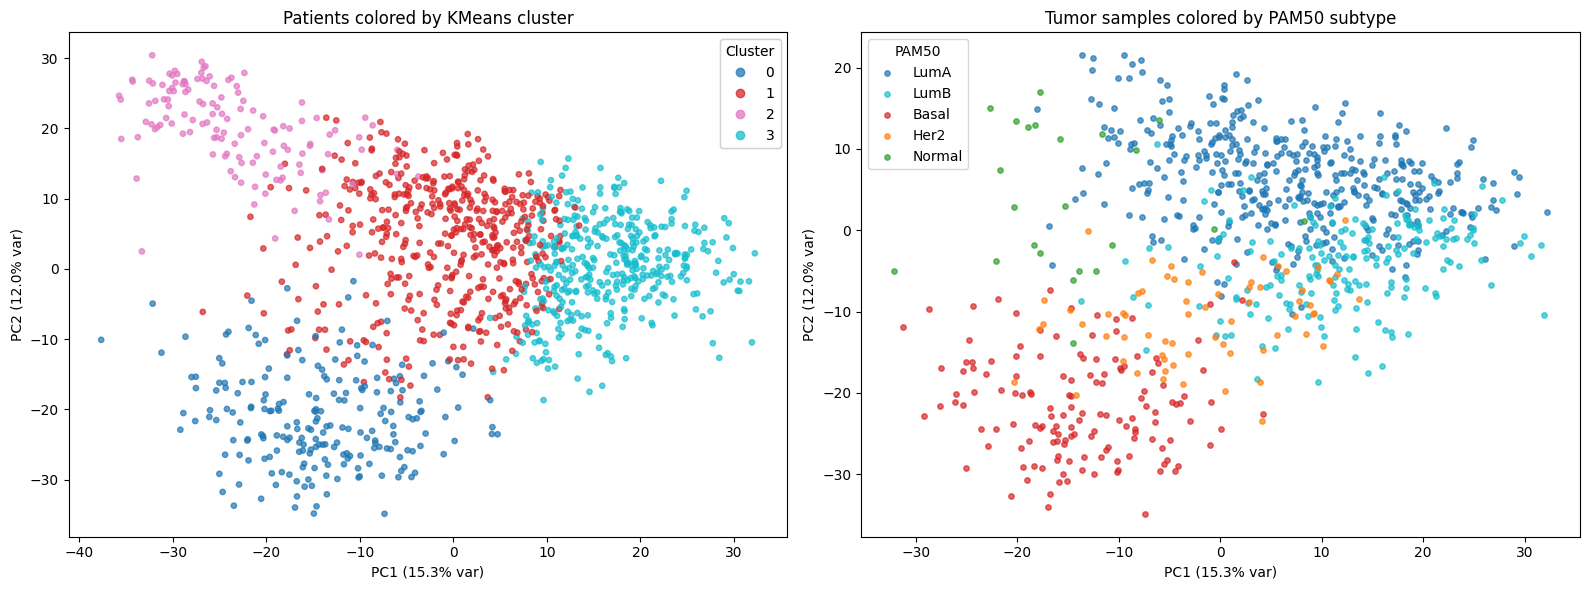

In [0]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by KMeans cluster
scatter1 = axes[0].scatter(
    plot_pdf["pc1"], plot_pdf["pc2"], c=plot_pdf["cluster"], cmap="tab10", s=15, alpha=0.7
)
axes[0].set_xlabel(f"PC1 ({explained_var_top[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({explained_var_top[1]*100:.1f}% var)")
axes[0].set_title("Patients colored by KMeans cluster")
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Cluster", loc="best")
axes[0].add_artist(legend1)

# Right: colored by PAM50 subtype (tumor samples only, matches Stage 5's ARI comparison)
pam50_colors = {"LumA": "tab:blue", "LumB": "tab:cyan", "Basal": "tab:red",
                 "Her2": "tab:orange", "Normal": "tab:green"}
tumor_plot = plot_pdf[plot_pdf["sample_type"] == "01"].dropna(subset=["PAM50Call_RNAseq"])

for subtype, color in pam50_colors.items():
    subset = tumor_plot[tumor_plot["PAM50Call_RNAseq"] == subtype]
    axes[1].scatter(subset["pc1"], subset["pc2"], c=color, s=15, alpha=0.7, label=subtype)

axes[1].set_xlabel(f"PC1 ({explained_var_top[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({explained_var_top[1]*100:.1f}% var)")
axes[1].set_title("Tumor samples colored by PAM50 subtype")
axes[1].legend(title="PAM50", loc="best")

plt.tight_layout()
plt.savefig("/tmp/pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization (Stage 7): Communicating the result
The side-by-side PCA scatter (cluster assignment vs. PAM50 subtype) makes
the ARI/contingency-table agreement visually verifiable in seconds --
critical for communicating results to a non-technical stakeholder who
won't parse a p-value table but can see two scatter plots line up.
Decision enabled: faster, higher-trust communication of results to
cross-functional teams (clinical, commercial, regulatory) who need to
act on the finding without re-deriving it themselves.

In [0]:
top15_display = biomarker_full.head(15)[
    ["gene_id", "f_stat", "p_value", "mean_cluster0", "mean_cluster1", "mean_cluster2", "mean_cluster3"]
].copy()
top15_display["f_stat"] = top15_display["f_stat"].round(1)
top15_display["p_value"] = top15_display["p_value"].apply(lambda x: f"{x:.2e}")
for c in ["mean_cluster0", "mean_cluster1", "mean_cluster2", "mean_cluster3"]:
    top15_display[c] = top15_display[c].round(2)

top15_display.to_csv("/tmp/top15_biomarkers.csv", index=False)
print(top15_display.to_string(index=False))

        gene_id  f_stat   p_value  mean_cluster0  mean_cluster1  mean_cluster2  mean_cluster3
ENSG00000129514  1408.8  0.00e+00           1.70           6.22           4.10           6.75
ENSG00000115648  1073.7  0.00e+00           1.75           5.63           4.00           5.92
ENSG00000054598  1022.7  0.00e+00           4.46           1.69           3.13           1.00
ENSG00000107485   837.7 7.49e-296           3.65           7.34           5.46           8.00
ENSG00000168497   803.6 1.76e-288           0.96           2.08           5.15           1.09
ENSG00000148468   784.9 2.37e-284           4.09           2.30           3.48           1.51
ENSG00000149090   784.2 3.46e-284           0.95           1.54           4.13           0.90
ENSG00000100219   777.8 9.08e-283           6.51           9.29           8.15           9.80
ENSG00000176532   745.3 2.13e-275           1.10           4.31           2.29           4.65
ENSG00000109436   731.9 2.75e-272           2.91           6